# Plant Species Classification with a Custom CNN

This notebook contains the final version of our custom CNN for classifying 14 plant species. 
The model is trained from scratch without pretrained weights.

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Ordner mit unserem final bereinigten Datensatz
DATA_DIR = Path("data_final")

# Klassen automatisch aus den Unterordnern auslesen
class_names = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])

class_to_index = {
    name: i
    for i, name in enumerate(class_names)
}

print("TensorFlow:", tf.__version__)
print("\nKlassen:")

for name, idx in class_to_index.items():
    print(f"{idx:2d}: {name}")

print("\nAnzahl Klassen:", len(class_names))

TensorFlow: 2.21.0

Klassen:
 0: birke
 1: bohne
 2: eibe
 3: eiche
 4: esche
 5: gemeiner_schneeball
 6: gerste
 7: hasel
 8: kirschblüte
 9: kuerbis
10: linde
11: mais
12: waldkiefer
13: weissdorn

Anzahl Klassen: 14


## 1. Dataset Preparation

The dataset contains images of 14 plant species. A fixed train-validation-test split is used to ensure that the final model is evaluated on the same data throughout the final experiments.

In [2]:
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

class_counts = {}

for class_name in class_names:
    class_dir = DATA_DIR / class_name
    
    images = [
        file for file in class_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]
    
    class_counts[class_name] = len(images)

print("Bilder pro Klasse:\n")

for class_name, count in class_counts.items():
    print(f"{class_name:22s}: {count:3d}")

print("\nGesamt:", sum(class_counts.values()))

Bilder pro Klasse:

birke                 : 138
bohne                 : 222
eibe                  : 209
eiche                 : 163
esche                 : 228
gemeiner_schneeball   : 114
gerste                : 217
hasel                 : 260
kirschblüte           : 100
kuerbis               : 283
linde                 : 219
mais                  : 299
waldkiefer            : 198
weissdorn             : 249

Gesamt: 2899


### Fixed Train-Validation-Test Split

The previously generated split is loaded from `final_split.csv` rather than generated again. This ensures reproducibility and prevents changes to the test set.

In [3]:
# Bereits festgelegten finalen Split wieder laden
split_df = pd.read_csv("final_split.csv")

train_df = split_df[split_df["split"] == "train"].copy()
val_df   = split_df[split_df["split"] == "val"].copy()
test_df  = split_df[split_df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2024
Val:   581
Test:  294


### TensorFlow Data Pipeline

The image paths and labels from the fixed split are converted into TensorFlow datasets for training, validation, and testing.

In [4]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)

    label = tf.one_hot(label, depth=len(class_names))

    return image, label


def make_dataset(df, training=False):
    paths = df["filepath"].astype(str).values
    labels = df["class"].map(class_to_index).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=42
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train = make_dataset(train_df, training=True)
val   = make_dataset(val_df, training=False)
test  = make_dataset(test_df, training=False)

print("Train:", len(train_df), "Bilder")
print("Val:  ", len(val_df), "Bilder")
print("Test: ", len(test_df), "Bilder")

for images, labels in train.take(1):
    print("Bild-Batch:", images.shape)
    print("Label-Batch:", labels.shape)
    print(
        "Pixelbereich:",
        float(tf.reduce_min(images)),
        "bis",
        float(tf.reduce_max(images))
    )

Train: 2024 Bilder
Val:   581 Bilder
Test:  294 Bilder
Bild-Batch: (32, 256, 256, 3)
Label-Batch: (32, 14)
Pixelbereich: 0.0 bis 255.0


### Class Weights

Class weights are calculated from the training set to reduce the influence of differences in class frequency during training.

In [9]:
from sklearn.utils.class_weight import compute_class_weight

# Klassenindizes der Trainingsbilder
y_train = train_df["class"].map(class_to_index).to_numpy()

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=y_train
)

class_weights = {
    i: weight for i, weight in enumerate(weights)
}

print("Class Weights:")
for i, weight in class_weights.items():
    print(f"{i:2d} {class_names[i]:22s}: {weight:.3f}")

Class Weights:
 0 birke                 : 1.506
 1 bohne                 : 0.933
 2 eibe                  : 0.990
 3 eiche                 : 1.268
 4 esche                 : 0.909
 5 gemeiner_schneeball   : 1.830
 6 gerste                : 0.957
 7 hasel                 : 0.794
 8 kirschblüte           : 2.065
 9 kuerbis               : 0.730
10 linde                 : 0.945
11 mais                  : 0.692
12 waldkiefer            : 1.048
13 weissdorn             : 0.831


In [5]:
num_classes = len(class_names)

print("Anzahl Klassen:", num_classes)

Anzahl Klassen: 14


## 2. Final CNN Architecture

The final model uses a custom CNN architecture trained entirely from scratch. Separable convolutions are used to increase feature-extraction capacity while keeping the number of parameters comparatively low.

In [6]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Rescaling,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    Conv2D,
    SeparableConv2D,
    BatchNormalization,
    ReLU,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

model_final_3 = Sequential([
    # Preprocessing + moderate augmentation
    Rescaling(1./255, input_shape=(256, 256, 3)),
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomZoom(0.05),

    # Initial standard convolution
    Conv2D(32, 3, padding="same"),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D(),

    # MobileNet-inspired separable convolution blocks
    SeparableConv2D(64, 3, padding="same"),
    BatchNormalization(),
    ReLU(),
    SeparableConv2D(64, 3, padding="same"),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D(),

    SeparableConv2D(128, 3, padding="same"),
    BatchNormalization(),
    ReLU(),
    SeparableConv2D(128, 3, padding="same"),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D(),

    SeparableConv2D(256, 3, padding="same"),
    BatchNormalization(),
    ReLU(),
    SeparableConv2D(256, 3, padding="same"),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D(),

    # Classification head
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model_final_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

model_final_3.summary()

/Users/jonnaporksen/Documents/GitHub/plant_scanner/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 128, 128, 64)   │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 128, 128, 64)   │         4,736 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 64, 64, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 64, 64, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 209,966 (820.18 KB)

 Trainable params: 208,110 (812.93 KB)

 Non-trainable params: 1,856 (7.25 KB)

## 3. Training

Early stopping and learning-rate reduction are used to control training and reduce unnecessary computation. The model with the lowest validation loss is saved as the final checkpoint.

In [7]:
early_stopping_3 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr_3 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint_3 = tf.keras.callbacks.ModelCheckpoint(
    filepath="plant_model_final_3_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [10]:
history_final_3 = model_final_3.fit(
    train,
    validation_data=val,
    epochs=30,
    class_weight=class_weights,
    callbacks=[
        early_stopping_3,
        reduce_lr_3,
        checkpoint_3
    ]
)

Epoch 1/30


/Users/jonnaporksen/Documents/GitHub/plant_scanner/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1299 - loss: 2.5749
Epoch 1: val_loss improved from None to 2.63804, saving model to plant_model_final_3_best.keras

Epoch 1: finished saving model to plant_model_final_3_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.1299 - loss: 2.5749 - val_accuracy: 0.1033 - val_loss: 2.6380 - learning_rate: 3.0000e-04
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1952 - loss: 2.3276
Epoch 2: val_loss improved from 2.63804 to 2.63464, saving model to plant_model_final_3_best.keras

Epoch 2: finished saving model to plant_model_final_3_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.1952 - loss: 2.3276 - val_accuracy: 0.0792 - val_loss: 2.6346 - learning_rate: 3.0000e-04
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2213 - loss: 2.2514
Epoch 3: val_loss improved from 2.63464 to 2.63077, saving model to plant_model_final_3_best.keras

Epoch 3: finished saving model to plant_model_f

## 4. Model Evaluation

The final model is evaluated on the previously unseen test set. Performance is assessed using overall accuracy and loss as well as class-specific precision, recall and F1-scores.

In [11]:
test_loss_3, test_accuracy_3 = model_final_3.evaluate(test, verbose=1)

print(f"Test Loss: {test_loss_3:.4f}")
print(f"Test Accuracy: {test_accuracy_3:.4f}")
print(f"Test Accuracy: {test_accuracy_3 * 100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 683ms/step - accuracy: 0.3571 - loss: 2.0145
Test Loss: 2.0145
Test Accuracy: 0.3571
Test Accuracy: 35.71%


### Class-Specific Performance

In [12]:
import numpy as np
from sklearn.metrics import classification_report

y_true_3 = []
y_pred_3 = []

for images, labels in test:
    predictions = model_final_3.predict(images, verbose=0)

    y_true_3.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_3.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true_3,
    y_pred_3,
    target_names=class_names,
    digits=3
))

                     precision    recall  f1-score   support

              birke      0.333     0.143     0.200        14
              bohne      0.565     0.565     0.565        23
               eibe      0.311     0.667     0.424        21
              eiche      0.455     0.294     0.357        17
              esche      0.267     0.174     0.211        23
gemeiner_schneeball      0.571     0.667     0.615        12
             gerste      0.394     0.591     0.473        22
              hasel      0.200     0.154     0.174        26
        kirschblüte      0.545     0.600     0.571        10
            kuerbis      0.390     0.552     0.457        29
              linde      0.333     0.273     0.300        22
               mais      0.192     0.167     0.179        30
         waldkiefer      0.333     0.350     0.341        20
          weissdorn      0.200     0.080     0.114        25

           accuracy                          0.357       294
          macro avg   

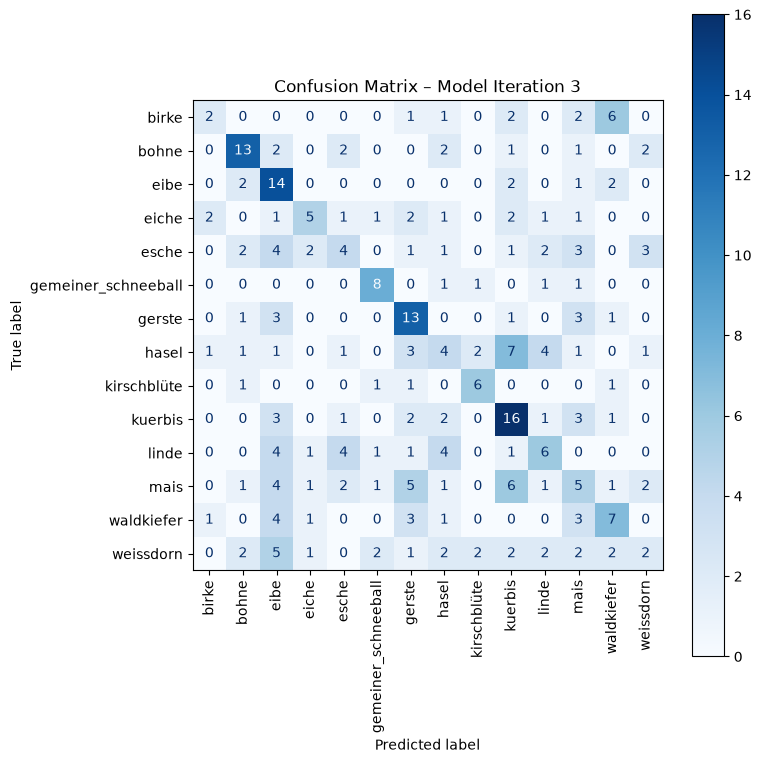

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_3 = confusion_matrix(y_true_3, y_pred_3)

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_3,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix – Model Iteration 3")
plt.tight_layout()
plt.show()

### Training History

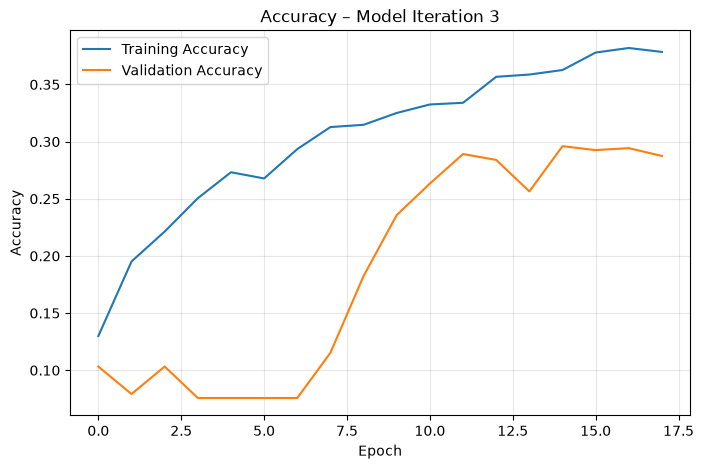

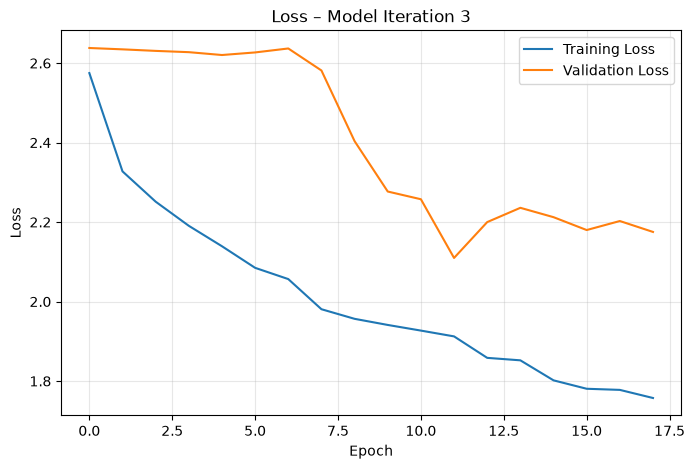

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_final_3.history["accuracy"], label="Training Accuracy")
plt.plot(history_final_3.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy – Model Iteration 3")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_final_3.history["loss"], label="Training Loss")
plt.plot(history_final_3.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss – Model Iteration 3")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [15]:
import numpy as np

best_epoch_3 = np.argmin(history_final_3.history["val_loss"])

print("Best epoch:", best_epoch_3 + 1)
print("Train Accuracy:", history_final_3.history["accuracy"][best_epoch_3])
print("Val Accuracy:", history_final_3.history["val_accuracy"][best_epoch_3])
print("Train Loss:", history_final_3.history["loss"][best_epoch_3])
print("Val Loss:", history_final_3.history["val_loss"][best_epoch_3])

if "learning_rate" in history_final_3.history:
    print("Learning Rate:", history_final_3.history["learning_rate"][best_epoch_3])

Best epoch: 12
Train Accuracy: 0.3339920938014984
Val Accuracy: 0.28915661573410034
Train Loss: 1.9123979806900024
Val Loss: 2.109814167022705
Learning Rate: 0.0001500000071246177
